In [1]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from jax.scipy.linalg import solve_triangular

# @jax.jit
def plummer_logp(pos, pos_cov, x0, y0, a, eps, theta):

    # Shift the positions according to the center (x0, y0).
    new_pos = jnp.array([pos[0] - x0, pos[1] - y0]).T

    # Rotate the positions and covariances according to the angle theta.
    cos_theta = jnp.cos(theta)
    sin_theta = jnp.sin(theta)

    rot_matrix = jnp.array(
        [
            [cos_theta, -sin_theta],
            [sin_theta, cos_theta],
        ]
    )
    pos_rotated = jnp.dot(new_pos, rot_matrix)

    cov_rotated = jnp.dot(rot_matrix, jnp.dot(pos_cov, rot_matrix).T).T

    # Calculate the Plummer profile log-likelihood.
    r2 = (pos_rotated[0] ** 2 + (pos_rotated[1] ** 2 / (1 - eps) ** 2)) / a**2
    r2_err = (cov_rotated[0, 0] + (cov_rotated[1, 1] / (1 - eps) ** 2)) / a**2

    r2_eff = r2 + r2_err

    logp = (
        -jnp.log(jnp.pi) - 2 * jnp.log(a) - jnp.log(1 - eps) - 2 * jnp.log(1 + r2_eff)
    )

    return logp


# @jax.jit
# def uniform_logp(pos):
#     x_min, x_max = jnp.min(pos[0]), jnp.max(pos[0])
#     y_min, y_max = jnp.min(pos[1]), jnp.max(pos[1])
#     area = (x_max - x_min) * (y_max - y_min)
#     return -jnp.log(area)


# @jax.jit
def pm_mvnormal_logp(pm, pm_cov, mura, mudec, chol_0, chol_1, chol_2):
    # Reconstruct model covariance from Cholesky parameters
    L_model = jnp.array([[chol_0, 0], [chol_1, chol_2]])
    model_cov = L_model @ L_model.T

    # Calculate total covariance for all stars
    total_cov = pm_cov + model_cov

    # Batch Cholesky decomposition
    L_total = jnp.linalg.cholesky(total_cov)

    # Compute terms for log probability
    diff = jnp.array([pm[0] - mura, pm[1] - mudec])
    D = 2  # Dimension

    # Log determinant using Cholesky diagonals
    log_det = 2 * jnp.sum(jnp.log(jnp.diag(L_total)))

    # Vectorized triangular solve (faster than regular solve for triangular matrices)
    y = solve_triangular(
        L_total,
        diff[..., jnp.newaxis],  # Add dimension for vectorized solve
        lower=True,
    ).squeeze(-1)

    # Quadratic term (vectorized dot product)
    quadratic_term = jnp.sum(y**2)

    # Combine all terms
    const_term = D * jnp.log(2 * jnp.pi)
    return -0.5 * (const_term + log_det + quadratic_term)


# @jax.jit
def loglikelihood(
    pos,
    pos_cov,
    pm,
    pm_cov,
    x0,
    y0,
    a,
    eps,
    theta,
    mura_gal,
    mudec_gal,
    chol_0_gal,
    chol_1_gal,
    chol_2_gal,
    mura_mw,
    mudec_mw,
    chol_0_mw,
    chol_1_mw,
    chol_2_mw,
    p,
):
    logp_plummer = plummer_logp(pos, pos_cov, x0, y0, a, eps, theta)
    logp_pm_gal = pm_mvnormal_logp(
        pm, pm_cov, mura_gal, mudec_gal, chol_0_gal, chol_1_gal, chol_2_gal
    )
    logp_gal = logp_plummer + logp_pm_gal

    logp_pos_mw = -17.763672610008292  # uniform_logp(pos)
    logp_pm_mw = pm_mvnormal_logp(
        pm, pm_cov, mura_mw, mudec_mw, chol_0_mw, chol_1_mw, chol_2_mw
    )
    logp_mw = logp_pos_mw + logp_pm_mw

    logp = jnp.sum(jnp.logaddexp(jnp.log(p) + logp_gal, jnp.log(1 - p) + logp_mw))

    return logp


def vectorized_loglikelihood(*args):
    vmap = jax.vmap(
        loglikelihood,
        in_axes=(
            0,
            0,
            0,
            0,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
        ),
    )
    return jnp.sum(vmap(*args))


jitted_vectorized_loglikelihood = jax.jit(vectorized_loglikelihood)

jitted_vectorized_loglikelihood_grad = jax.jit(
    jax.grad(vectorized_loglikelihood, argnums=list(range(20)))
)

In [2]:
from astropy.table import Table
import numpy as np

from astropy.coordinates import SkyCoord

RetII = SkyCoord("03h35m47.83s", "−54d02m47.80s")

RetIIPM = Table.read(
    "/home/vwetzell/Documents/Processed_RETII_v1/RetII_v0.0/RetIIPM_GAIA_PSF_MAG_APER_8_EXTMASH.fits"
)

RetIIPM = RetIIPM[RetIIPM["pm_1"] < 20]

gaia_stars = ~np.isnan(RetIIPM["pm_2"])

RetIIPM["pm"] = RetIIPM["pm_1"]
RetIIPM["pm"][gaia_stars] = RetIIPM["pm_2"][gaia_stars]

RetIIPM["pmra"] = RetIIPM["pmra_1"]
RetIIPM["pmra"][gaia_stars] = RetIIPM["pmra_2"][gaia_stars]

RetIIPM["pmdec"] = RetIIPM["pmdec_1"]
RetIIPM["pmdec"][gaia_stars] = RetIIPM["pmdec_2"][gaia_stars]

RetIIPM["ra"] = RetIIPM["ra_1"]
RetIIPM["ra"][gaia_stars] = RetIIPM["ra_2"][gaia_stars]

RetIIPM["dec"] = RetIIPM["dec_1"]
RetIIPM["dec"][gaia_stars] = RetIIPM["dec_2"][gaia_stars]

RetIIPM["c_xx"] = RetIIPM["c_xx"]
RetIIPM["c_xx"][gaia_stars] = ((RetIIPM["ra_error"] / 1000) ** 2)[gaia_stars]

RetIIPM["c_yy"] = RetIIPM["c_yy"]
RetIIPM["c_yy"][gaia_stars] = ((RetIIPM["dec_error"] / 1000) ** 2)[gaia_stars]

RetIIPM["c_xy"] = RetIIPM["c_xy"]
RetIIPM["c_xy"][gaia_stars] = (
    (RetIIPM["ra_error"] / 1000)
    * (RetIIPM["dec_error"] / 1000)
    * RetIIPM["ra_dec_corr"]
)[gaia_stars]

RetIIPM["c_vxvx"] = RetIIPM["c_vxvx"]
RetIIPM["c_vxvx"][gaia_stars] = ((RetIIPM["pmra_error"] / 1000) ** 2)[gaia_stars]

RetIIPM["c_vyvy"] = RetIIPM["c_vyvy"]
RetIIPM["c_vyvy"][gaia_stars] = ((RetIIPM["pmdec_error"] / 1000) ** 2)[gaia_stars]

RetIIPM["c_vxvy"] = RetIIPM["c_vxvy"]
RetIIPM["c_vxvy"][gaia_stars] = (
    (RetIIPM["pmra_error"] / 1000)
    * (RetIIPM["pmdec_error"] / 1000)
    * RetIIPM["pmra_pmdec_corr"]
)[gaia_stars]

RetIIPM = RetIIPM[(RetIIPM["dof"] > 25) | gaia_stars]


eps = 0.6
hlr = 6.3 / 60 * np.sqrt(1 - eps)

RetIIPM["dAlpha"] = (RetIIPM["ra"] - RetII.ra.value) * np.cos(
    (np.pi / 180) * RetII.dec.value
)
RetIIPM["dDelta"] = RetIIPM["dec"] - RetII.dec.value

RetIIpos, xedges, yedges = np.histogram2d(
    RetIIPM["dAlpha"], RetIIPM["dDelta"], bins=100
)

In [3]:
import numpy as np

eps = 0.6
hlr = 6.3 / 60 * np.sqrt(1 - eps)
theta = 68 * np.pi / 180

n_hlr = 8

from ugali import isochrone

E = 2.0
delmu = 0.5
c1 = 0.05
c2 = 0.1


def err(mag_g):
    return 0.05 + np.exp((mag_g - 27.09) / 1.09)


feh = -2.4

mu = 5 * np.log10(31.4 * 1000) - 5

iso = isochrone.factory(
    name="Dotter2008", age=13.5, distance_modulus=mu, metallicity=10**feh
)

g_lo = 16
g_hi = 23

mag_cut = (RetIIPM["PSF_MAG_APER_8_G"] < g_hi) & (RetIIPM["PSF_MAG_APER_8_G"] > g_lo)

color_ids = [
    i
    for i in range(len(RetIIPM))
    if (RetIIPM["PSF_MAG_APER_8_G"][i] - RetIIPM["PSF_MAG_APER_8_R"][i])
    > (
        0.0
        + iso.mag_1[
            np.argmin(
                np.abs(
                    RetIIPM["PSF_MAG_APER_8_G"][i] - iso.mag_1 - iso.distance_modulus
                )
            )
        ]
        - iso.mag_2[
            np.argmin(
                np.abs(
                    RetIIPM["PSF_MAG_APER_8_G"][i] - iso.mag_1 - iso.distance_modulus
                )
            )
        ]
        - (
            E
            * err(
                iso.mag_1[
                    np.argmin(
                        np.abs(
                            RetIIPM["PSF_MAG_APER_8_G"][i]
                            - iso.mag_1
                            - iso.distance_modulus
                        )
                    )
                ]
                + iso.distance_modulus
                + delmu / 2
            )
        )
        - c1
    )
    and (RetIIPM["PSF_MAG_APER_8_G"][i] - RetIIPM["PSF_MAG_APER_8_R"][i])
    < (
        0.0
        + iso.mag_1[
            np.argmin(
                np.abs(
                    RetIIPM["PSF_MAG_APER_8_G"][i] - iso.mag_1 - iso.distance_modulus
                )
            )
        ]
        - iso.mag_2[
            np.argmin(
                np.abs(
                    RetIIPM["PSF_MAG_APER_8_G"][i] - iso.mag_1 - iso.distance_modulus
                )
            )
        ]
        + (
            E
            * err(
                iso.mag_1[
                    np.argmin(
                        np.abs(
                            RetIIPM["PSF_MAG_APER_8_G"][i]
                            - iso.mag_1
                            - iso.distance_modulus
                        )
                    )
                ]
                + iso.distance_modulus
                - delmu / 2
            )
        )
        + c2
    )
]


color_cut = np.zeros_like(mag_cut, dtype=bool)
color_cut[color_ids] = True

RetIIPM_gr_cut = RetIIPM[mag_cut & color_cut]
len(RetIIPM_gr_cut)

3158

In [4]:
pos = np.array([RetIIPM_gr_cut["dAlpha"], RetIIPM_gr_cut["dDelta"]]).T
pos_cov = np.array(
    [
        [RetIIPM_gr_cut["c_xx"], RetIIPM_gr_cut["c_xy"]],
        [RetIIPM_gr_cut["c_xy"], RetIIPM_gr_cut["c_xx"]],
    ]
).T
proper_motions = np.array([RetIIPM_gr_cut["pmra"], RetIIPM_gr_cut["pmdec"]]).T
pm_cov = np.array(
    [
        [RetIIPM_gr_cut["c_vxvx"], RetIIPM_gr_cut["c_vxvy"]],
        [RetIIPM_gr_cut["c_vxvy"], RetIIPM_gr_cut["c_vyvy"]],
    ]
).T

loglikelihood(
    pos=pos[0],
    pos_cov=pos_cov[0],
    pm=proper_motions[0],
    pm_cov=pm_cov[0],
    x0=0.0,
    y0=0.0,
    a=6.3 / 60,
    eps=0.6,
    theta=(90 - 68) * np.pi / 180,
    mura_gal=0,
    mudec_gal=0,
    chol_0_gal=0.1,
    chol_1_gal=0.0,
    chol_2_gal=0.1,
    mura_mw=0,
    mudec_mw=0,
    chol_0_mw=0.1,
    chol_1_mw=0.0,
    chol_2_mw=0.1,
    p=0.28,
)

Array(-1593.3557, dtype=float32)

In [5]:
jitted_vectorized_loglikelihood_grad(
    pos,
    pos_cov,
    proper_motions,
    pm_cov,
    0.0,
    0.0,
    6.3 / 60,
    0.6,
    (90 - 68) * np.pi / 180,
    0.0,
    0.0,
    1.0,
    0.0,
    1.0,
    0.0,
    0.0,
    1.0,
    0.0,
    1.0,
    0.28,
)[5]

Array(1050.3091, dtype=float32, weak_type=True)

In [6]:
import pytensor
import pytensor.tensor as pt

from pytensor.graph import Apply, Op


class LogLikelihoodOp(Op):
    def make_node(
        self,
        pos,
        pos_cov,
        pm,
        pm_cov,
        x0,
        y0,
        a,
        eps,
        theta,
        mura_gal,
        mudec_gal,
        chol_0_gal,
        chol_1_gal,
        chol_2_gal,
        mura_mw,
        mudec_mw,
        chol_0_mw,
        chol_1_mw,
        chol_2_mw,
        p,
    ):
        inputs = [
            pt.as_tensor_variable(pos),
            pt.as_tensor_variable(pos_cov),
            pt.as_tensor_variable(pm),
            pt.as_tensor_variable(pm_cov),
            pt.as_tensor_variable(x0),
            pt.as_tensor_variable(y0),
            pt.as_tensor_variable(a),
            pt.as_tensor_variable(eps),
            pt.as_tensor_variable(theta),
            pt.as_tensor_variable(mura_gal),
            pt.as_tensor_variable(mudec_gal),
            pt.as_tensor_variable(chol_0_gal),
            pt.as_tensor_variable(chol_1_gal),
            pt.as_tensor_variable(chol_2_gal),
            pt.as_tensor_variable(mura_mw),
            pt.as_tensor_variable(mudec_mw),
            pt.as_tensor_variable(chol_0_mw),
            pt.as_tensor_variable(chol_1_mw),
            pt.as_tensor_variable(chol_2_mw),
            pt.as_tensor_variable(p),
        ]

        outputs = [pt.dscalar()]
        return Apply(
            self,
            inputs,
            outputs,
        )

    def perform(self, node, inputs, outputs):
        result = jitted_vectorized_loglikelihood(*inputs)
        outputs[0][0] = np.asarray(result, dtype=node.outputs[0].dtype)

    def grad(self, inputs, output_grads):
        (
            grad_wrt_pos,
            grad_wrt_pos_cov,
            grad_wrt_pm,
            grad_wrt_pm_cov,
            grad_wrt_x0,
            grad_wrt_y0,
            grad_wrt_a,
            grad_wrt_eps,
            grad_wrt_theta,
            grad_wrt_mura_gal,
            grad_wrt_mudec_gal,
            grad_wrt_chol_0_gal,
            grad_wrt_chol_1_gal,
            grad_wrt_chol_2_gal,
            grad_wrt_mura_mw,
            grad_wrt_mudec_mw,
            grad_wrt_chol_0_mw,
            grad_wrt_chol_1_mw,
            grad_wrt_chol_2_mw,
            grad_wrt_p,
        ) = loglikelihood_grad_op(*inputs)

        output_grads = output_grads[0]
        return [
            output_grads * grad_wrt_pos,
            output_grads * grad_wrt_pos_cov,
            output_grads * grad_wrt_pm,
            output_grads * grad_wrt_pm_cov,
            output_grads * grad_wrt_x0,
            output_grads * grad_wrt_y0,
            output_grads * grad_wrt_a,
            output_grads * grad_wrt_eps,
            output_grads * grad_wrt_theta,
            output_grads * grad_wrt_mura_gal,
            output_grads * grad_wrt_mudec_gal,
            output_grads * grad_wrt_chol_0_gal,
            output_grads * grad_wrt_chol_1_gal,
            output_grads * grad_wrt_chol_2_gal,
            output_grads * grad_wrt_mura_mw,
            output_grads * grad_wrt_mudec_mw,
            output_grads * grad_wrt_chol_0_mw,
            output_grads * grad_wrt_chol_1_mw,
            output_grads * grad_wrt_chol_2_mw,
            output_grads * grad_wrt_p,
        ]


class LoglikelihoodGradOp(Op):
    def make_node(
        self,
        pos,
        pos_cov,
        pm,
        pm_cov,
        x0,
        y0,
        a,
        eps,
        theta,
        mura_gal,
        mudec_gal,
        chol_0_gal,
        chol_1_gal,
        chol_2_gal,
        mura_mw,
        mudec_mw,
        chol_0_mw,
        chol_1_mw,
        chol_2_mw,
        p,
    ):

        inputs = [
            pt.as_tensor_variable(pos),
            pt.as_tensor_variable(pos_cov),
            pt.as_tensor_variable(pm),
            pt.as_tensor_variable(pm_cov),
            pt.as_tensor_variable(x0),
            pt.as_tensor_variable(y0),
            pt.as_tensor_variable(a),
            pt.as_tensor_variable(eps),
            pt.as_tensor_variable(theta),
            pt.as_tensor_variable(mura_gal),
            pt.as_tensor_variable(mudec_gal),
            pt.as_tensor_variable(chol_0_gal),
            pt.as_tensor_variable(chol_1_gal),
            pt.as_tensor_variable(chol_2_gal),
            pt.as_tensor_variable(mura_mw),
            pt.as_tensor_variable(mudec_mw),
            pt.as_tensor_variable(chol_0_mw),
            pt.as_tensor_variable(chol_1_mw),
            pt.as_tensor_variable(chol_2_mw),
            pt.as_tensor_variable(p),
        ]

        return Apply(
            self,
            inputs,
            [inp.type() for inp in inputs],
        )

    def perform(self, node, inputs, outputs):
        (
            grad_wrt_pos,
            grad_wrt_pos_cov,
            grad_wrt_pm,
            grad_wrt_pm_cov,
            grad_wrt_x0,
            grad_wrt_y0,
            grad_wrt_a,
            grad_wrt_eps,
            grad_wrt_theta,
            grad_wrt_mura_gal,
            grad_wrt_mudec_gal,
            grad_wrt_chol_0_gal,
            grad_wrt_chol_1_gal,
            grad_wrt_chol_2_gal,
            grad_wrt_mura_mw,
            grad_wrt_mudec_mw,
            grad_wrt_chol_0_mw,
            grad_wrt_chol_1_mw,
            grad_wrt_chol_2_mw,
            grad_wrt_p,
        ) = jitted_vectorized_loglikelihood_grad(*inputs)

        outputs[0][0] = np.asarray(grad_wrt_pos, dtype=node.outputs[0].dtype)
        outputs[1][0] = np.asarray(grad_wrt_pos_cov, dtype=node.outputs[1].dtype)
        outputs[2][0] = np.asarray(grad_wrt_pm, dtype=node.outputs[2].dtype)
        outputs[3][0] = np.asarray(grad_wrt_pm_cov, dtype=node.outputs[3].dtype)
        outputs[4][0] = np.asarray(grad_wrt_x0, dtype=node.outputs[4].dtype)
        outputs[5][0] = np.asarray(grad_wrt_y0, dtype=node.outputs[5].dtype)
        outputs[6][0] = np.asarray(grad_wrt_a, dtype=node.outputs[6].dtype)
        outputs[7][0] = np.asarray(grad_wrt_eps, dtype=node.outputs[7].dtype)
        outputs[8][0] = np.asarray(grad_wrt_theta, dtype=node.outputs[8].dtype)
        outputs[9][0] = np.asarray(grad_wrt_mura_gal, dtype=node.outputs[9].dtype)
        outputs[10][0] = np.asarray(grad_wrt_mudec_gal, dtype=node.outputs[10].dtype)
        outputs[11][0] = np.asarray(grad_wrt_chol_0_gal, dtype=node.outputs[11].dtype)
        outputs[12][0] = np.asarray(grad_wrt_chol_1_gal, dtype=node.outputs[12].dtype)
        outputs[13][0] = np.asarray(grad_wrt_chol_2_gal, dtype=node.outputs[13].dtype)
        outputs[14][0] = np.asarray(grad_wrt_mura_mw, dtype=node.outputs[14].dtype)
        outputs[15][0] = np.asarray(grad_wrt_mudec_mw, dtype=node.outputs[15].dtype)
        outputs[16][0] = np.asarray(grad_wrt_chol_0_mw, dtype=node.outputs[16].dtype)
        outputs[17][0] = np.asarray(grad_wrt_chol_1_mw, dtype=node.outputs[17].dtype)
        outputs[18][0] = np.asarray(grad_wrt_chol_2_mw, dtype=node.outputs[18].dtype)
        outputs[19][0] = np.asarray(grad_wrt_p, dtype=node.outputs[19].dtype)


loglikelihood_op = LogLikelihoodOp()
loglikelihood_grad_op = LoglikelihoodGradOp()

In [7]:
jitted_vectorized_loglikelihood_grad(
    pos,
    pos_cov,
    proper_motions,
    pm_cov,
    0.0,
    0.0,
    6.3 / 60,
    0.6,
    (90 - 68) * np.pi / 180,
    0.0,
    0.0,
    1.0,
    0.0,
    1.0,
    0.0,
    0.0,
    1.0,
    0.0,
    1.0,
    0.28,
)

(Array([[ 1.0631483, -5.29597  ],
        [-1.9812031, -4.602371 ],
        [-4.8555   ,  4.3498487],
        ...,
        [ 1.790062 ,  8.710716 ],
        [ 5.0958414,  5.418006 ],
        [ 3.0587254, -4.4646854]], dtype=float32),
 Array([[[-6.9039237e-01, -3.9339066e-06],
         [ 8.8453293e-04, -4.3178964e+00]],
 
        [[-1.8526528e+00,  4.1246414e-05],
         [-3.3187866e-04, -1.1577267e+01]],
 
        [[-1.7336888e+00,  1.6832352e-04],
         [ 5.3405762e-05, -1.0827209e+01]],
 
        ...,
 
        [[-4.2232337e+00, -5.6695938e-04],
         [ 3.4332275e-05, -2.6389782e+01]],
 
        [[-6.1005535e+00,  5.7029724e-04],
         [-5.5847168e-03, -3.8120850e+01]],
 
        [[-7.3047078e-01,  1.3363361e-04],
         [ 2.6845932e-04, -4.5667081e+00]]], dtype=float32),
 Array([[-5.593572  , -0.6868281 ],
        [-3.8674345 , -0.05427461],
        [-3.6364403 , -0.3692154 ],
        ...,
        [-1.3100293 ,  0.27434355],
        [-4.9624906 ,  3.0636725 ],
        [

In [8]:
loglikelihood_grad_op(
    pos,
    pos_cov,
    proper_motions,
    pm_cov,
    0.0,
    0.0,
    6.3 / 60,
    0.6,
    (90 - 68) * np.pi / 180,
    0.0,
    0.0,
    1.0,
    0.0,
    1.0,
    0.0,
    0.0,
    1.0,
    0.0,
    1.0,
    0.28,
)[4].eval()

array(-1406.7173, dtype=float32)

In [27]:
import pymc as pm

pos = 3600 * np.array([RetIIPM_gr_cut["dAlpha"], RetIIPM_gr_cut["dDelta"]]).T
pos_cov = np.array(
    [
        [RetIIPM_gr_cut["c_xx"], RetIIPM_gr_cut["c_xy"]],
        [RetIIPM_gr_cut["c_xy"], RetIIPM_gr_cut["c_xx"]],
    ]
).T
proper_motions = np.array([RetIIPM_gr_cut["pmra"], RetIIPM_gr_cut["pmdec"]]).T / 1000
pm_cov = np.array(
    [
        [RetIIPM_gr_cut["c_vxvx"], RetIIPM_gr_cut["c_vxvy"]],
        [RetIIPM_gr_cut["c_vxvy"], RetIIPM_gr_cut["c_vyvy"]],
    ]
).T


with pm.Model() as model:
    pos = pm.Data("pos", pos)
    pos_cov = pm.Data("pos_cov", pos_cov)
    proper_motions = pm.Data("pm", proper_motions)
    pm_cov = pm.Data("pm_cov", pm_cov)

    ra_gal = pm.Normal("ra_gal", mu=0, sigma=0.5 / 60)
    dec_gal = pm.Normal("dec_gal", mu=0, sigma=0.5 / 60)

    ra_gal = ra_gal * 3600
    dec_gal = dec_gal * 3600

    a = pm.Normal("a", mu=6.3, sigma=0.5)
    a = a * 60

    eps = pm.TruncatedNormal("eps", mu=0.6, sigma=0.1, lower=0, upper=1)

    theta = pm.TruncatedNormal("theta", mu=68, sigma=15, lower=0, upper=180)

    theta = (90 - theta) * np.pi / 180

    pmra_gal = pm.Normal("pmra_gal", mu=2.36, sigma=0.5)
    pmdec_gal = pm.Normal("pmdec_gal", mu=-1.32, sigma=0.5)

    pmra_gal = pmra_gal / 1000
    pmdec_gal = pmdec_gal / 1000

    chol_gal = pm.LKJCholeskyCov(
        "chol_gal", 2, 2, pm.Exponential.dist(scale=0.01), compute_corr=False
    )

    unpacked_chol_gal = pm.expand_packed_triangular(2, chol_gal)
    Sigma_gal = unpacked_chol_gal.dot(unpacked_chol_gal.T)

    sigma_gal_ra = pm.Deterministic("sigma_gal_ra", np.sqrt(Sigma_gal[0, 0]))
    sigma_gal_dec = pm.Deterministic("sigma_gal_dec", np.sqrt(Sigma_gal[1, 1]))

    (chol_gal_0, chol_gal_1, chol_gal_2) = chol_gal

    chol_gal_0 = chol_gal_0 / 1000
    chol_gal_1 = chol_gal_1 / 1000
    chol_gal_2 = chol_gal_2 / 1000

    pmra_mw = pm.Normal("pmra_mw", mu=0, sigma=3)
    pmdec_mw = pm.Normal("pmdec_mw", mu=0, sigma=3)

    pmra_mw = pmra_mw / 1000
    pmdec_mw = pmdec_mw / 1000

    chol_mw = pm.LKJCholeskyCov(
        "chol_mw", 2, 2, pm.Exponential.dist(scale=1.5), compute_corr=False
    )

    unpacked_chol_mw = pm.expand_packed_triangular(2, chol_mw)
    Sigma_mw = unpacked_chol_mw.dot(unpacked_chol_mw.T)

    sigma_mw_ra = pm.Deterministic("sigma_mw_ra", np.sqrt(Sigma_mw[0, 0]))
    sigma_mw_dec = pm.Deterministic("sigma_mw_dec", np.sqrt(Sigma_mw[1, 1]))

    (chol_mw_0, chol_mw_1, chol_mw_2) = chol_mw

    chol_mw_0 = chol_mw_0 / 1000
    chol_mw_1 = chol_mw_1 / 1000
    chol_mw_2 = chol_mw_2 / 1000

    p = pm.Beta("p", mu=0.25, sigma=0.1)

    loglike = pm.Potential(
        "logp",
        loglikelihood_op(
            pos=pos,
            pos_cov=pos_cov,
            pm=proper_motions,
            pm_cov=pm_cov,
            x0=ra_gal,
            y0=dec_gal,
            a=a,
            eps=eps,
            theta=theta,
            mura_gal=pmra_gal,
            mudec_gal=pmdec_gal,
            chol_0_gal=chol_gal_0,
            chol_1_gal=chol_gal_1,
            chol_2_gal=chol_gal_2,
            mura_mw=pmra_mw,
            mudec_mw=pmdec_mw,
            chol_0_mw=chol_mw_0,
            chol_1_mw=chol_mw_1,
            chol_2_mw=chol_mw_2,
            p=p,
        ),
    )

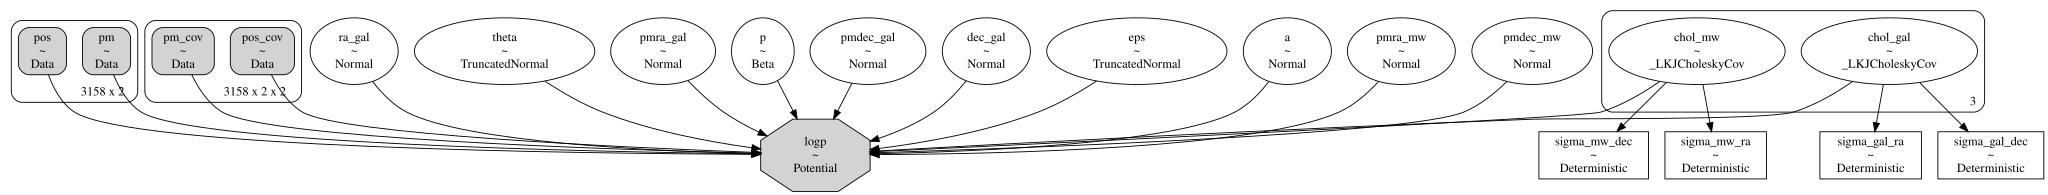

In [28]:
pm.model_to_graphviz(model)

In [29]:
# with model:
#     idata = pm.sample(
#         draws=1000,
#         tune=1000,
#         chains=4,
#         cores=1,
#         target_accept=0.9,
#         # nuts_sampler="numpyro",
#     )

In [30]:
from pytensor.link.jax.dispatch import jax_funcify


@jax_funcify.register(LogLikelihoodOp)
def loglike_dispatch(op, **kwargs):
    return vectorized_loglikelihood

In [31]:
out = loglikelihood_op(
    pos,
    pos_cov,
    proper_motions,
    pm_cov,
    0.0,
    0.0,
    6.3 / 60,
    0.6,
    (90 - 68) * np.pi / 180,
    0.0,
    0.0,
    1.0,
    0.0,
    1.0,
    0.0,
    0.0,
    1.0,
    0.0,
    1.0,
    0.28,
)
jax_fn = pytensor.function(inputs=[], outputs=out, mode="JAX")
jax_fn()

Array(-62933.5638124, dtype=float64)

In [32]:
initial_point = model.initial_point()
initial_point

{'ra_gal': array(0.),
 'dec_gal': array(0.),
 'a': array(6.3),
 'eps_interval__': array(0.),
 'theta_interval__': array(0.),
 'pmra_gal': array(2.36),
 'pmdec_gal': array(-1.32),
 'chol_gal_cholesky-cov-packed__': array([0., 0., 0.]),
 'pmra_mw': array(0.),
 'pmdec_mw': array(0.),
 'chol_mw_cholesky-cov-packed__': array([0., 0., 0.]),
 'p_logodds__': array(-1.09861229)}

In [33]:
model_loglike_jax_fn = model.compile_fn(model.logp(sum=False), mode="JAX")
model_loglike_jax_fn(initial_point)

[Array(3.86855321, dtype=float64),
 Array(3.86855321, dtype=float64),
 Array(-0.22579135, dtype=float64),
 Array(-0.50261613, dtype=float64),
 Array(-0.89587887, dtype=float64),
 Array(-0.22579135, dtype=float64),
 Array(-0.22579135, dtype=float64),
 Array(-190.50197756, dtype=float64),
 Array(-2.01755084, dtype=float64),
 Array(-2.01755084, dtype=float64),
 Array(-1.85658145, dtype=float64),
 Array(-0.33804626, dtype=float64),
 Array(-58936.48983757, dtype=float64)]

In [34]:
import pymc.sampling.jax as pmjax

with model:
    idata_numpyro = pmjax.sample_numpyro_nuts(
        draws=10000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        progressbar=False,
    )

/home/vwetzell/miniconda3/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


In [17]:
import arviz as az

az.summary(idata_numpyro)
idata_numpyro.to_netcdf("RetII_allgaia_wide_gr_0.95.nc")

'RetII_allgaia_wide_gr_0.95.nc'

In [18]:
import arviz as az

idata_numpyro_allgaia = az.from_netcdf("RetII_allgaia.nc")
# idata_numpyro_nogaia = az.from_netcdf("RetII.nc")

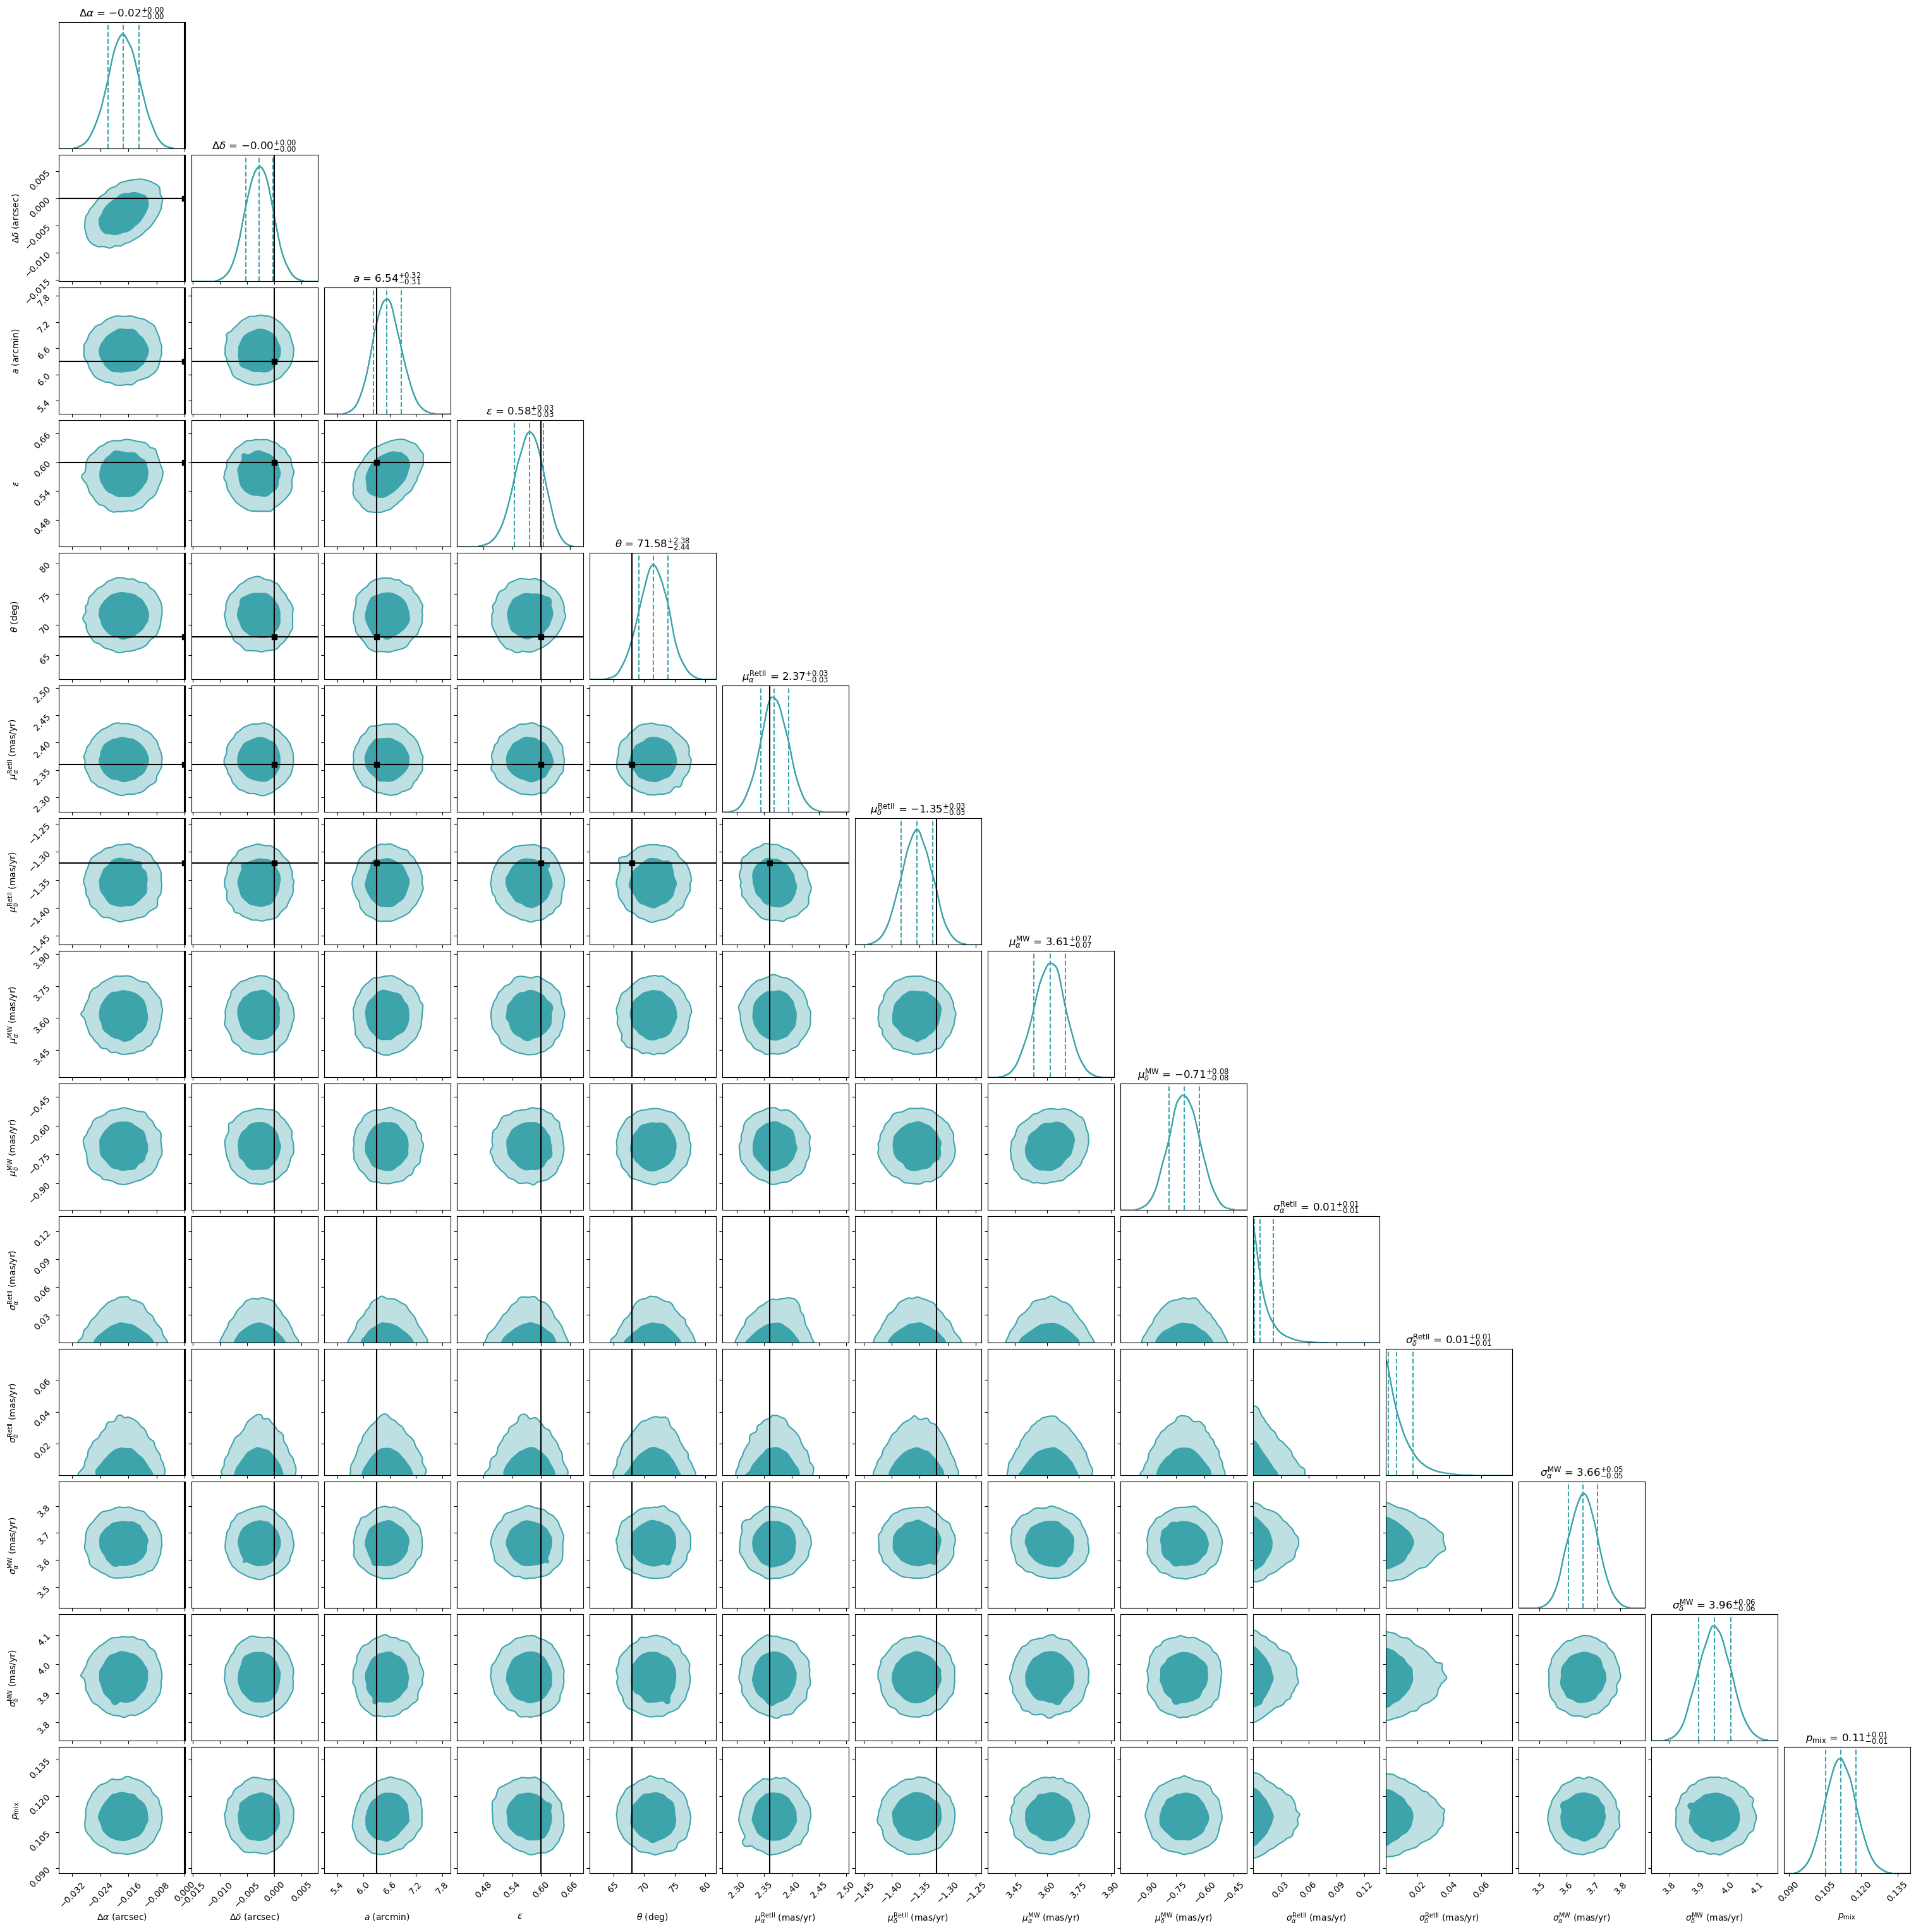

In [35]:
import corner

import matplotlib.pyplot as plt

fig = corner.corner(
    idata_numpyro,
    var_names=[
        "ra_gal",
        "dec_gal",
        "a",
        "eps",
        "theta",
        "pmra_gal",
        "pmdec_gal",
        "pmra_mw",
        "pmdec_mw",
        "sigma_gal_ra",
        "sigma_gal_dec",
        "sigma_mw_ra",
        "sigma_mw_dec",
        "p",
    ],
    labels=[
        r"$\Delta\alpha$ (arcsec)",
        r"$\Delta\delta$ (arcsec)",
        r"$a$ (arcmin)",
        r"$\epsilon$",
        r"$\theta$ (deg)",
        r"$\mu_\alpha^\text{RetII}$ (mas/yr)",
        r"$\mu_\delta^\text{RetII}$ (mas/yr)",
        r"$\mu_\alpha^\text{MW}$ (mas/yr)",
        r"$\mu_\delta^\text{MW}$ (mas/yr)",
        r"$\sigma_{\alpha}^\text{RetII}$ (mas/yr)",
        r"$\sigma_{\delta}^\text{RetII}$ (mas/yr)",
        r"$\sigma_{\alpha}^\text{MW}$ (mas/yr)",
        r"$\sigma_{\delta}^\text{MW}$ (mas/yr)",
        r"$p_\text{mix}$",
    ],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".2f",
    bins=1000,
    smooth=20,
    smooth1d=20,
    plot_datapoints=False,
    plot_density=False,
    levels=(0.68, 0.95),
    fill_contours=True,
    color="#3da4ab",
    truths=[
        0,
        0,
        6.3,
        0.6,
        68,
        2.36,
        -1.32,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
    ],
    truth_color="k",
)

import re

# Remove the parameter names from the titles
for ax in fig.axes:
    title = ax.get_title()
    new_title = re.sub(r"\s*\(.*?\)", "", ax.get_title())
    ax.set_title(new_title)

# corner.corner(
#     idata_numpyro_allgaia,
#     var_names=[
#         "ra_gal",
#         "dec_gal",
#         "a",
#         "eps",
#         "theta",
#         "pmra_gal",
#         "pmdec_gal",
#         "pmra_mw",
#         "pmdec_mw",
#         "sigma_gal_ra",
#         "sigma_gal_dec",
#         "sigma_mw_ra",
#         "sigma_mw_dec",
#         "p",
#     ],
#     labels=[
#         r"$\Delta\alpha$ (arcsec)",
#         r"$\Delta\delta$ (arcsec)",
#         r"$a$ (arcmin)",
#         r"$\epsilon$",
#         r"$\theta$ (deg)",
#         r"$\mu_\alpha^\text{RetII}$ (mas/yr)",
#         r"$\mu_\delta^\text{RetII}$ (mas/yr)",
#         r"$\mu_\alpha^\text{MW}$ (mas/yr)",
#         r"$\mu_\delta^\text{MW}$ (mas/yr)",
#         r"$\sigma_{\alpha}^\text{RetII}$ (mas/yr)",
#         r"$\sigma_{\delta}^\text{RetII}$ (mas/yr)",
#         r"$\sigma_{\alpha}^\text{MW}$ (mas/yr)",
#         r"$\sigma_{\delta}^\text{MW}$ (mas/yr)",
#         r"$p_\text{mix}$",
#     ],
#     bins=1000,
#     smooth=20,
#     smooth1d=20,
#     plot_datapoints=False,
#     plot_density=False,
#     levels=(0.68, 0.95),
#     color="#fe8a71",
#     fig=fig,
# )

plt.savefig("RetII_corner.png", dpi=300)
plt.show()

In [36]:
def compute_membership_probabilities(
    pos,
    pos_cov,
    pm,
    pm_cov,
    x0,
    y0,
    a,
    eps,
    theta,
    mura_gal,
    mudec_gal,
    chol_0_gal,
    chol_1_gal,
    chol_2_gal,
    mura_mw,
    mudec_mw,
    chol_0_mw,
    chol_1_mw,
    chol_2_mw,
    p,
):
    logp_gal = plummer_logp(pos, pos_cov, x0, y0, a, eps, theta)
    logp_pm_gal = pm_mvnormal_logp(
        pm, pm_cov, mura_gal, mudec_gal, chol_0_gal, chol_1_gal, chol_2_gal
    )
    logp_gal = logp_gal + logp_pm_gal

    logp_mw = -17.763672610008292
    logp_pm_mw = pm_mvnormal_logp(
        pm, pm_cov, mura_mw, mudec_mw, chol_0_mw, chol_1_mw, chol_2_mw
    )

    logp_mw = logp_mw + logp_pm_mw

    membership_prob = (p * jnp.exp(logp_gal)) / (
        (p * jnp.exp(logp_gal)) + ((1 - p) * jnp.exp(logp_mw))
    )

    return membership_prob


def vectorized_membership_probabilities(*args):
    vmap = jax.vmap(
        compute_membership_probabilities,
        in_axes=(
            0,
            0,
            0,
            0,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
            None,
        ),
    )
    return vmap(*args)


pos = 3600 * np.array([RetIIPM_gr_cut["dAlpha"], RetIIPM_gr_cut["dDelta"]]).T
pos_cov = np.array(
    [
        [RetIIPM_gr_cut["c_xx"], RetIIPM_gr_cut["c_xy"]],
        [RetIIPM_gr_cut["c_xy"], RetIIPM_gr_cut["c_xx"]],
    ]
).T
proper_motions = np.array([RetIIPM_gr_cut["pmra"], RetIIPM_gr_cut["pmdec"]]).T / 1000
pm_cov = np.array(
    [
        [RetIIPM_gr_cut["c_vxvx"], RetIIPM_gr_cut["c_vxvy"]],
        [RetIIPM_gr_cut["c_vxvy"], RetIIPM_gr_cut["c_vyvy"]],
    ]
).T

membership_prob = vectorized_membership_probabilities(
    pos,
    pos_cov,
    proper_motions,
    pm_cov,
    3600 * idata_numpyro.posterior["ra_gal"].median().values.astype(float),
    3600 * idata_numpyro.posterior["dec_gal"].median().values.astype(float),
    idata_numpyro.posterior["a"].median().values.astype(float),
    idata_numpyro.posterior["eps"].median().values.astype(float),
    (90 - idata_numpyro.posterior["theta"].median().values.astype(float)) * np.pi / 180,
    idata_numpyro.posterior["pmra_gal"].median().values.astype(float) / 1000,
    idata_numpyro.posterior["pmdec_gal"].median().values.astype(float) / 1000,
    idata_numpyro.posterior["chol_gal"].median(axis=(0, 1)).values[0].astype(float)
    / 1000,
    idata_numpyro.posterior["chol_gal"].median(axis=(0, 1)).values[1].astype(float)
    / 1000,
    idata_numpyro.posterior["chol_gal"].median(axis=(0, 1)).values[2].astype(float)
    / 1000,
    idata_numpyro.posterior["pmra_mw"].median().values.astype(float) / 1000,
    idata_numpyro.posterior["pmdec_mw"].median().values.astype(float) / 1000,
    idata_numpyro.posterior["chol_mw"].median(axis=(0, 1)).values[0].astype(float)
    / 1000,
    idata_numpyro.posterior["chol_mw"].median(axis=(0, 1)).values[1].astype(float)
    / 1000,
    idata_numpyro.posterior["chol_mw"].median(axis=(0, 1)).values[2].astype(float)
    / 1000,
    idata_numpyro.posterior["p"].median().values.astype(float),
)

membership_prob

Array([1.08092293e-225, 1.84138723e-006, 3.25966989e-006, ...,
       8.12854330e-006, 2.27724764e-005, 5.40339067e-256], dtype=float64)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


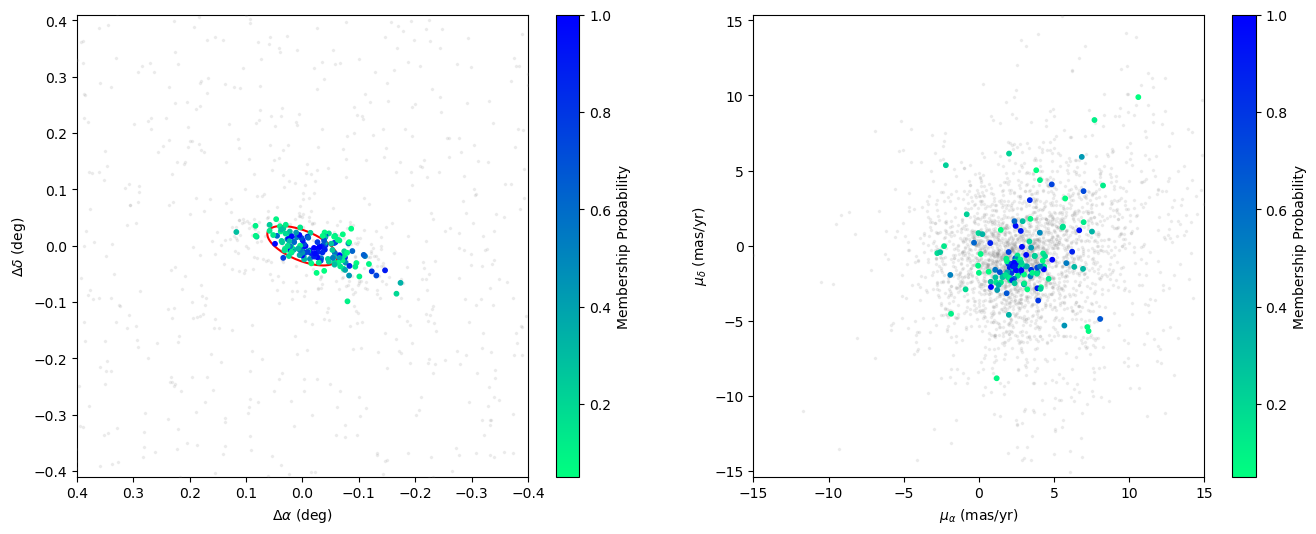

In [39]:
eps = 0.6
hlr = 6.3 / 60 * np.sqrt(1 - eps)
theta = 68 * np.pi / 180

n_hlr = 1

z = np.linspace(0, 2 * np.pi, 1000)

x = n_hlr * hlr * np.array([np.cos(z), np.sin(z) * (1 - eps)]).T

ra_hlr, dec_hlr = np.einsum(
    "...ij,...i",
    np.array(
        [
            [np.cos(theta + np.pi / 2), -np.sin(theta + np.pi / 2)],
            [np.sin(theta + np.pi / 2), np.cos(theta + np.pi / 2)],
        ]
    )[np.newaxis, :, :],
    x,
).T

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
pcm = ax[0].scatter(
    RetIIPM_gr_cut["dAlpha"][membership_prob > 0.05],
    RetIIPM_gr_cut["dDelta"][membership_prob > 0.05],
    c=membership_prob[membership_prob > 0.05],
    s=10,
    cmap="winter_r",
    alpha=1,
    vmin=0.05,
    vmax=1,
    marker="o",
    zorder=20,
)
ax[0].scatter(
    RetIIPM_gr_cut["dAlpha"][membership_prob < 0.05],
    RetIIPM_gr_cut["dDelta"][membership_prob < 0.05],
    s=10,
    c="grey",
    alpha=0.1,
    marker=".",
    zorder=10,
)
ax[0].plot(ra_hlr, dec_hlr, c="r")
fig.colorbar(pcm, ax=ax[0], label="Membership Probability")
ax[0].set_xlabel(r"$\Delta\alpha$ (deg)")
ax[0].set_ylabel(r"$\Delta\delta$ (deg)")
ax[0].axis("equal")
ax[0].set_xlim(-0.4, 0.4)
ax[0].set_ylim(-0.4, 0.4)
ax[0].invert_xaxis()


pcm = ax[1].scatter(
    RetIIPM_gr_cut["pmra"][membership_prob > 0.05],
    RetIIPM_gr_cut["pmdec"][membership_prob > 0.05],
    c=membership_prob[membership_prob > 0.05],
    s=10,
    cmap="winter_r",
    alpha=1,
    vmin=0.05,
    vmax=1,
    marker="o",
    zorder=20,
)
ax[1].scatter(
    RetIIPM_gr_cut["pmra"][membership_prob < 0.05],
    RetIIPM_gr_cut["pmdec"][membership_prob < 0.05],
    s=10,
    c="grey",
    alpha=0.1,
    marker=".",
    zorder=10,
)
fig.colorbar(pcm, ax=ax[1], label="Membership Probability")
ax[1].set_xlabel(r"$\mu_\alpha$ (mas/yr)")
ax[1].set_ylabel(r"$\mu_\delta$ (mas/yr)")
ax[1].axis("equal")
ax[1].set_xlim(-15, 15)
ax[1].set_ylim(-15, 15)
plt.show()

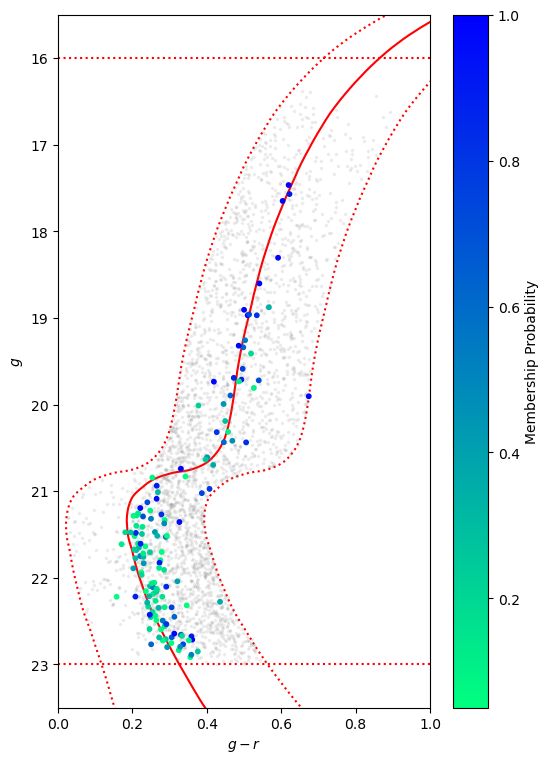

In [40]:
from ugali import isochrone

E = 2.0
delmu = 0.5
c1 = 0.05
c2 = 0.1


def err(mag_g):
    return 0.05 + np.exp((mag_g - 27.09) / 1.09)


feh = -2.4

mu = 5 * np.log10(31.4 * 1000) - 5

iso = isochrone.factory(
    name="Dotter2008", age=13.5, distance_modulus=mu, metallicity=10**feh
)


plt.figure(figsize=(6, 9))
plt.scatter(
    (RetIIPM_gr_cut["PSF_MAG_APER_8_G"] - RetIIPM_gr_cut["PSF_MAG_APER_8_R"])[membership_prob > 0.05],
    (RetIIPM_gr_cut["PSF_MAG_APER_8_G"])[membership_prob > 0.05],
    c=membership_prob[membership_prob > 0.05],
    s=10,
    cmap="winter_r",
    alpha=1,
    vmin=0.05,
    vmax=1,
    marker="o",
    zorder=20
)
plt.colorbar(label="Membership Probability")
plt.scatter(
    (RetIIPM_gr_cut["PSF_MAG_APER_8_G"] - RetIIPM_gr_cut["PSF_MAG_APER_8_R"])[membership_prob < 0.05],
    (RetIIPM_gr_cut["PSF_MAG_APER_8_G"])[membership_prob < 0.05],
    s=10,
    c="grey",
    alpha=0.1,
    marker=".",
    zorder=10
)

plt.plot(
    0.0 + iso.mag_1[:350] - iso.mag_2[:350],
    iso.mag_1[:350] + iso.distance_modulus,
    c="r",
    label="Dotter Isochrone",
)

plt.plot(
    0.0
    + iso.mag_1[:350]
    - iso.mag_2[:350]
    - (E * err(iso.mag_1[:350] + iso.distance_modulus + delmu / 2))
    - c1,
    iso.mag_1[:350] + iso.distance_modulus,
    c="r",
    ls=":",
    label="Modified Matched-Filter Selection",
)

plt.plot(
    0.0
    + iso.mag_1[:350]
    - iso.mag_2[:350]
    + (E * err(iso.mag_1[:350] + iso.distance_modulus - delmu / 2))
    + c2,
    iso.mag_1[:350] + iso.distance_modulus,
    c="r",
    ls=":",
)

plt.axhline(16, c="r", ls=":")
plt.axhline(23, c="r", ls=":")


plt.xlabel(r"$g - r$")
plt.ylabel(r"$g$")
plt.ylim(15.5, 23.5)
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.show()